# 04 - Deep Learning model: DistilBERT (fine-tuned transformer)
**NLP Deliverable 2 — modern ML approach #2 (strong DL model)**

We fine-tune a pretrained **DistilBERT** (`distilbert-base-cased`) for token
classification. Unlike the BiLSTM trained from scratch, this model starts from
language-model weights learned on large corpora, so it transfers much better and
is expected to be the strongest model overall.

Key technical point: BERT tokenizers split words into **sub-words**, so word-level
tags must be *aligned* to sub-word tokens (label on the first sub-token, `-100`
on the rest so they are ignored by the loss).

Saved artifacts (used by `05_reproduce_results.ipynb`):
`fitted_models/distilbert_ner/` (HF model + tokenizer) and `fitted_models/distilbert_labels.pkl`.

> Colab-friendly: auto-detects **cuda / mps / cpu**. On GPU it fine-tunes on the full
> dataset; on CPU it falls back to a smaller subset / 1 epoch so the notebook still
> runs end-to-end (re-run on Colab GPU for the final model).

In [1]:
# === Setup (works locally and on Google Colab) ===
import sys, os
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install -q transformers seqeval
    DATA_DIR = '.'                  # adjust to where you uploaded the CSVs
else:
    DATA_DIR = '../nlp_d2_data'
FITTED_DIR = 'fitted_models'
os.makedirs(FITTED_DIR, exist_ok=True)

import warnings; warnings.filterwarnings('ignore')
import pickle, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForTokenClassification
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
sns.set_theme(style='whitegrid')

device = torch.device('cuda' if torch.cuda.is_available()
                      else 'mps' if torch.backends.mps.is_available() else 'cpu')
FULL = device.type == 'cuda'        # full training only worthwhile on GPU
print('Device:', device, '| FULL training:', FULL)

MODEL_NAME = 'distilbert-base-cased'
# Training config: full on GPU, lightweight fallback on CPU so it still runs locally
N_TRAIN = None if FULL else 3000    # cap #train sentences when on CPU
EPOCHS  = 3 if FULL else 1
BATCH   = 16
MAX_LEN = 64
LR      = 3e-5

Device: cpu | FULL training: False


## 1. Load data (grouped by sentence)

In [2]:
def load_data(path):
    df = pd.read_csv(path)
    df['words'] = df['words'].astype(str)
    df['sentence_id'] = df['sentence_id'].astype(int)
    return [list(zip(g['words'].tolist(), g['tags'].tolist()))
            for _, g in df.groupby('sentence_id', sort=True)]

train_sents = load_data(os.path.join(DATA_DIR, 'train_data_ner.csv'))
test_sents  = load_data(os.path.join(DATA_DIR, 'test_data_ner.csv'))
if N_TRAIN:
    train_sents = train_sents[:N_TRAIN]
print(f'train: {len(train_sents)} | test: {len(test_sents)}')

train: 3000 | test: 38367


## 2. Label mappings

In [3]:
# Build label set from the FULL train file (so all tags are present even if subset-training)
all_tags = pd.read_csv(os.path.join(DATA_DIR, 'train_data_ner.csv'))['tags'].astype(str).unique()
label_list = sorted(all_tags.tolist())
label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for l, i in label2id.items()}

with open(os.path.join(FITTED_DIR, 'distilbert_labels.pkl'), 'wb') as fh:
    pickle.dump({'label2id': label2id, 'id2label': id2label,
                 'label_list': label_list, 'max_len': MAX_LEN,
                 'model_name': MODEL_NAME}, fh)
print('labels:', label_list)

labels: ['B-art', 'B-eve', 'B-geo', 'B-gpe', 'B-nat', 'B-org', 'B-per', 'B-tim', 'I-art', 'I-eve', 'I-geo', 'I-gpe', 'I-nat', 'I-org', 'I-per', 'I-tim', 'O']


## 3. Tokenization + sub-word label alignment

Each sentence is tokenized with `is_split_into_words=True`. We use `word_ids()` to map
each sub-token back to its original word, putting the real label on the first sub-token
of a word and `-100` (ignored by the loss) on the continuation sub-tokens and special
tokens.

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class NERDataset(Dataset):
    def __init__(self, sents, tok, l2i, max_len):
        self.sents, self.tok, self.l2i, self.max_len = sents, tok, l2i, max_len
    def __len__(self):
        return len(self.sents)
    def __getitem__(self, idx):
        words = [w for w, _ in self.sents[idx]]
        tags  = [t for _, t in self.sents[idx]]
        enc = self.tok(words, is_split_into_words=True, truncation=True,
                       max_length=self.max_len, padding='max_length',
                       return_tensors='pt')
        word_ids = enc.word_ids(0)
        labels, prev = [], None
        for wid in word_ids:
            if wid is None:
                labels.append(-100)
            elif wid != prev:
                labels.append(self.l2i[tags[wid]])
            else:
                labels.append(-100)        # continuation sub-token
            prev = wid
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item['labels'] = torch.tensor(labels)
        return item

train_ds = NERDataset(train_sents, tokenizer, label2id, MAX_LEN)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
print('train batches:', len(train_loader))

train batches: 188


## 4. Fine-tuning

In [5]:
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME, num_labels=len(label_list), id2label=id2label, label2id=label2id
).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

model.train()
for epoch in range(EPOCHS):
    total = 0.0
    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        optimizer.zero_grad()
        out = model(**batch)
        out.loss.backward()
        optimizer.step()
        total += out.loss.item()
    print(f'Epoch {epoch+1}/{EPOCHS} - loss {total/len(train_loader):.4f}')

save_path = os.path.join(FITTED_DIR, 'distilbert_ner')
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)
print('Saved', save_path)

Some weights of DistilBertForTokenClassification were not initialized from the model checkpoint at distilbert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/1 - loss 0.3650


Saved fitted_models/distilbert_ner


## 5. Evaluation

In [6]:
@torch.no_grad()
def predict(model, sents, batch_size=32):
    """Return word-level predicted tags (one per original word) for each sentence."""
    model.eval()
    preds = []
    for start in range(0, len(sents), batch_size):
        chunk = sents[start:start+batch_size]
        batch_words = [[w for w, _ in s] for s in chunk]
        enc = tokenizer(batch_words, is_split_into_words=True, truncation=True,
                        max_length=MAX_LEN, padding=True, return_tensors='pt').to(device)
        logits = model(**enc).logits
        pred_ids = logits.argmax(-1).cpu().tolist()
        for b, s in enumerate(chunk):
            word_ids = enc.word_ids(b)
            seq, prev = [], None
            for tok_pos, wid in enumerate(word_ids):
                if wid is not None and wid != prev:
                    seq.append(id2label[pred_ids[b][tok_pos]])
                prev = wid
            # safety: align length to #words
            words = [w for w, _ in s]
            if len(seq) < len(words):
                seq += ['O'] * (len(words) - len(seq))
            preds.append(seq[:len(words)])
    return preds

def flatten(seq): return [x for sub in seq for x in sub]
def non_o_accuracy(yt, yp):
    yt, yp = flatten(yt), flatten(yp)
    idx = [k for k, t in enumerate(yt) if t != 'O']
    return accuracy_score([yt[k] for k in idx], [yp[k] for k in idx])
def weighted_f1(yt, yp):
    yt, yp = flatten(yt), flatten(yp)
    labels = sorted(set(yt) - {'O'})
    return f1_score(yt, yp, average='weighted', labels=labels, zero_division=0)

y_train = [[t for _, t in s] for s in train_sents]
y_test  = [[t for _, t in s] for s in test_sents]
yp_train = predict(model, train_sents)
yp_test  = predict(model, test_sents)
print(f"Train non-O accuracy: {non_o_accuracy(y_train, yp_train):.4f} | F1: {weighted_f1(y_train, yp_train):.4f}")
print(f"Test  non-O accuracy: {non_o_accuracy(y_test,  yp_test):.4f} | F1: {weighted_f1(y_test,  yp_test):.4f}")

Train non-O accuracy: 0.7808 | F1: 0.7835


Test  non-O accuracy: 0.5852 | F1: 0.5901


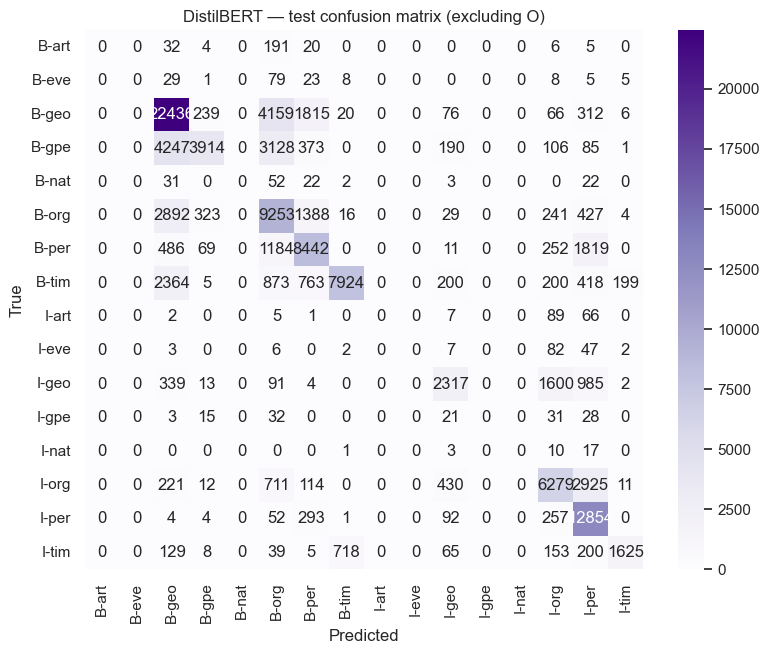

In [7]:
yt, yp = flatten(y_test), flatten(yp_test)
labels = sorted(set(yt) - {'O'})
cm = confusion_matrix(yt, yp, labels=labels)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=labels, yticklabels=labels)
plt.title('DistilBERT — test confusion matrix (excluding O)')
plt.ylabel('True'); plt.xlabel('Predicted'); plt.show()

## 6. TINY TEST

In [8]:
tiny_sents = load_data(os.path.join(DATA_DIR, 'tiny_test.csv'))
y_tiny = [[t for _, t in s] for s in tiny_sents]
yp_tiny = predict(model, tiny_sents)
print('=== TINY TEST — DistilBERT ===')
for s, pred in zip(tiny_sents, yp_tiny):
    print(' '.join(f'{w}/{t}' for (w, _), t in zip(s, pred)))
print(f'\nTiny-test accuracy (non-O): {non_o_accuracy(y_tiny, yp_tiny):.4f}')

=== TINY TEST — DistilBERT ===
The/O programmers/O from/O Barcelona/B-geo might/O write/O a/O sentence/O without/O a/O spell/O checker/O ./O
The/O programmers/O from/O Barchelona/B-geo cannot/O write/O a/O sentence/O without/O a/O spell/O checker/O ./O
Jack/B-per London/I-per went/O to/O Parris/B-geo ./O
Jack/B-per London/I-per went/O to/O Paris/B-geo ./O
Bill/O gates/O and/O Steve/B-per jobs/I-per never/O thought/O Microsoft/B-org would/O become/O such/O a/O big/O company/O ./O
Bill/B-per Gates/I-per and/O Steve/B-per Jobs/I-per never/O thought/O Microsoft/B-org would/O become/O such/O a/O big/O company/O ./O
The/O president/O of/O U.S.A/B-geo thought/O they/O could/O win/O the/O war/O ./O
The/O president/O of/O the/O United/B-geo States/I-geo of/O America/I-geo thought/O they/O could/O win/O the/O war/O ./O
The/O king/O of/O Saudi/B-geo Arabia/I-geo wanted/O total/O control/O ./O
Robin/B-per does/O not/O want/O to/O go/O to/O Saudi/B-geo Arabia/I-geo ./O
Apple/B-org is/O a/O great/O 

## 7. Notes
- DistilBERT transfers knowledge from large-scale pretraining, so it usually beats both
  the CRF and the from-scratch BiLSTM, especially on rare / unseen tokens.
- Word-level tags are aligned to sub-word tokens (label on first sub-token, `-100` on the
  rest) — the standard HF token-classification recipe.
- **CPU fallback**: locally we train on a `N_TRAIN` subset for 1 epoch only so the
  notebook runs end-to-end. Re-run on **Colab GPU** (`FULL=True`) to fine-tune on the full
  dataset for the final, best model.